In [ ]:
import torch

In [ ]:
x=torch.arange(4.0)
x

In [ ]:
x.requires_grad_(True)
x.grad

In [ ]:
y=2*torch.dot(x,x)
y

In [ ]:
y.backward()
x.grad

In [ ]:
x.grad == 4*x

In [ ]:
x.grad.zero_()
y=x.sum()
y.backward()
x.grad

In [ ]:
x.grad.zero_()
y=x*x
y.sum().backward()
x.grad

In [ ]:
x.grad.zero_()
y=x*x
u=y.detach()
z=u*x

z.sum().backward()
x.grad==u


In [ ]:
u

In [ ]:
x.grad.zero_()
y.sum().backward()
x.grad == 2*x

In [ ]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c


In [ ]:
a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()



In [ ]:
a.grad == d / a


In [ ]:
a.grad

In [ ]:
a

# Exercise

In [1]:
import torch
import math

任务A：求 y = x²·sin(x) 在 x=π/2 处的导数

我的解答：y对于x的导数是2x+cos(x)
正确答案：2x·sin(x)+x²·cos(x)

In [ ]:
x = math.pi / 2
y_grad = 2*x*math.sin(x) + x*x*math.cos(x)


In [ ]:
torch.allclose(torch.tensor(y_grad), torch.tensor(math.pi))

任务B：f = (a+b)·c（取 a=2、b=3、c=4）。先在纸上画计算图（a,b→s=a+b→f=s·c）再用 autograd 验证

手工画图计算
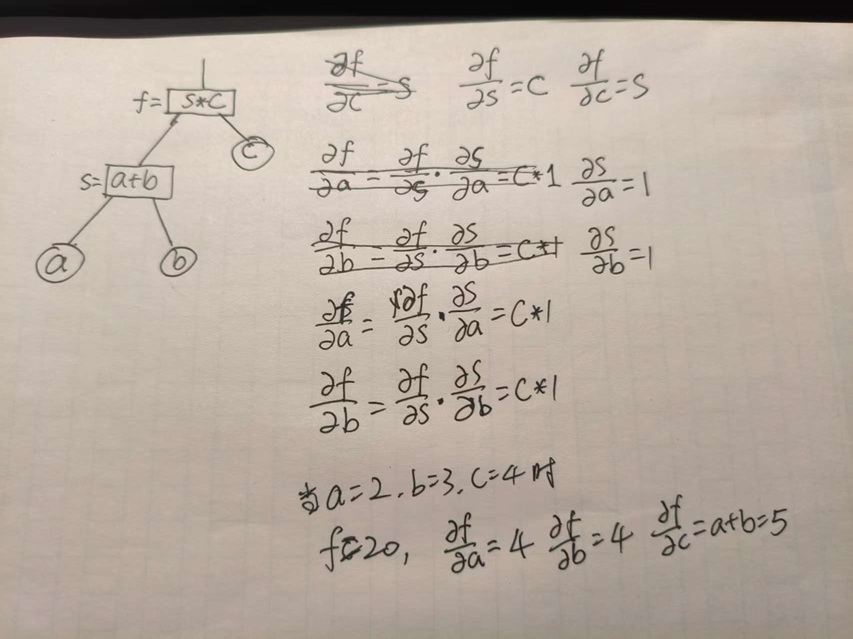

In [ ]:
def f(a, b, c):
    return (a+b)*c

a = torch.tensor(2., requires_grad=True)
b = torch.tensor(3., requires_grad=True)
c = torch.tensor(4., requires_grad=True)
y=f(a,b,c)
y



In [ ]:
y.backward()
print(a.grad, b.grad, c.grad)
a.grad.zero_()
b.grad.zero_()
c.grad.zero_()

一个 notebook 特有的坑：重复运行 y.backward() 这一行（图在第一次 backward 后已被释放）会报 Trying to backward through the graph a second time。从头跑一遍 cell、把图重新建出来即可。

In [ ]:
#更优写法
y.backward()
print(f"y={y.item()}, df/da={a.grad.item()}, df/db={b.grad.item()}, df/dc={c.grad.item()}")
assert torch.allclose(a.grad, torch.tensor(4.))
assert torch.allclose(b.grad, torch.tensor(4.))
assert torch.allclose(c.grad, torch.tensor(5.))

任务C（坑①·梯度累积）：对同一个 x 连续 backward 两次不清零，打印 grad 观察翻倍，再用 x.grad.zero_() 修复（末尾下划线=原地操作）

In [6]:
import torch

In [ ]:
x=torch.tensor(2.,requires_grad=True)


In [ ]:
y=x**2
y.backward()
x.grad

In [ ]:
y=x**2
y.backward()
x.grad

In [ ]:
x.grad.zero_()

In [ ]:
y=x**2
y.backward()
x.grad

任务D：跑书上 2.5.3 的 detach 例子并解释为什么 x.grad == u

In [5]:
x = torch.arange(4.0,requires_grad=True)
y=x*x
u=y.detach()
z=u*x

z.sum().backward()

print(x.grad, x.grad==u)

tensor([0., 1., 4., 9.]) tensor([True, True, True, True])


我的回答：u具有和y相同的值，但是y的计算过程不被存在计算图中，所以在z=u*x中，u被当成常数处理，所以z关于x的偏导数就是u

两处措辞修正：

“y 的计算过程不被存在计算图中”——准确说法是：u 和 y 数值相同，但 u 本身不在计算图里（它没有 grad_fn，requires_grad=False，相当于一张新图的“假叶子”）。y = x*x 那张图还在，只是梯度从 z 流到 u 就断头了——u 到 x 之间没有通路。detach 切断的不是“记忆”，是“回流”。
“z 关于 x 的偏导数就是 u”——严格说是 z.sum() 对 x 的梯度是 u，即逐分量 ∂(Σuᵢxᵢ)/∂xᵢ = uᵢ。别忘了 backward 的对象是 z.sum()——这正是 2.5.2 教的“非标量先求和”，你的答案里顺带用上了它，很好。

任务E（2.5.4·动态图，约10分钟）：跑书上的控制流函数 f(a)，取 a=1.0 / -1.0 / 0.001 各验证一次 a.grad == d/a（实测 k 分别为 1024 / 102400 / 1048576，把"k 怎么来的"手推进注释

In [9]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c
a=torch.tensor(1.0,requires_grad=True)
b=torch.tensor(-1.0,requires_grad=True)
c=torch.tensor(1*10**-3,requires_grad=True)
d1=f(a)
d2=f(b)
d3=f(c)
d1.backward()
d2.backward()
d3.backward()

print(a.grad,b.grad,c.grad)
a.grad.zero_()
b.grad.zero_()
c.grad.zero_()

tensor(1024.) tensor(102400.) tensor(1048576.)


tensor(0.)

我的解答


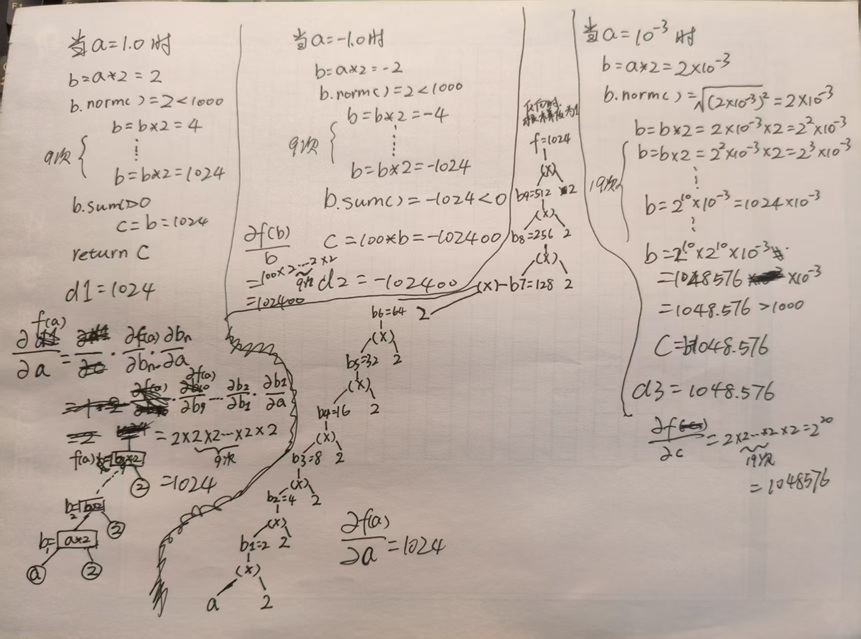


函数一路执行下来其实就是a*2...*2,乘了多个2，所以可以抽象为f(a)=k*a,那么导数就等于f(a)/a

计算图画法
第 1 步：找输入和输出。 输入是所有原始变量（requires_grad=True 的叶子张量），输出是最终那个数（训练里就是 loss，永远一个标量）。

第 2 步：把表达式拆成“一次一个基本运算”，给每个中间结果起名字。 基本运算就是 autograd 认识的那些：+ − × ÷、幂、sin/exp/log、sum、norm……(a+b)·c 拆成两次运算：s = a+b，f = s·c。

第 3 步：按数据流动方向画节点和箭头——值从哪个运算流进哪个运算，箭头就怎么指。输入在左（叶子），输出在右（根）

任务B:  f = (a+b)·c          任务A:  y = x²·sin(x)

a ──┐                        x ──(²)──→ u ──┐
    ├─(+)──→ s ──┐                          ├─(×)──→ y
b ──┘            ├─(×)──→ f   x ──(sin)─→ v ──┘
c ───────────────┘

标注习惯（画完图之后怎么用）
节点上方写前向值：如 s=5、f=20，从左往右算（forward）；
边上写局部梯度：× 节点对 s 的局部梯度是 c、对 c 的是 s；反向时从根出发（根的梯度预填 1），沿边往回走、逐段乘，遇到分叉就相加——这两个动作就是链式法则和乘法法则的全部；